In [47]:
# Cell 1
import pandas as pd

In [48]:
# Load the dataset
data = pd.read_csv("Salary_Data.csv")

# Display top and bottom rows
print(data.head(10))

    Age  Gender Education Level              Job Title  Years of Experience  \
0  32.0    Male      Bachelor's      Software Engineer                  5.0   
1  28.0  Female        Master's           Data Analyst                  3.0   
2  45.0    Male             PhD         Senior Manager                 15.0   
3  36.0  Female      Bachelor's        Sales Associate                  7.0   
4  52.0    Male        Master's               Director                 20.0   
5  29.0    Male      Bachelor's      Marketing Analyst                  2.0   
6  42.0  Female        Master's        Product Manager                 12.0   
7  31.0    Male      Bachelor's          Sales Manager                  4.0   
8  26.0  Female      Bachelor's  Marketing Coordinator                  1.0   
9  38.0    Male             PhD       Senior Scientist                 10.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  
5   55000.0  
6  120000.0  
7   80000.0  
8   

In [49]:
# Display bottom rows
print(data.tail(3))

       Age  Gender    Education Level          Job Title  Years of Experience  \
6701  30.0  Female  Bachelor's Degree  Financial Manager                  4.0   
6702  46.0    Male    Master's Degree  Marketing Manager                 14.0   
6703  26.0  Female        High School    Sales Executive                  1.0   

        Salary  
6701   55000.0  
6702  140000.0  
6703   35000.0  


In [50]:
# Shape of the dataset
print("Shape of the dataset:", data.shape)

# Check for missing values
print("\nMissing values:\n", data.isna().sum())

Shape of the dataset: (6704, 6)

Missing values:
 Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64


In [51]:
#Gender Distribution
print(data['Gender'].value_counts())

Gender
Male      3674
Female    3014
Other       14
Name: count, dtype: int64


In [52]:
#Fill Missing Genders
data['Gender'] = data['Gender'].fillna('Other')
print(data['Gender'].value_counts())


Gender
Male      3674
Female    3014
Other       16
Name: count, dtype: int64


In [53]:
#Education Level Distribution
print(data['Education Level'].value_counts())


Education Level
Bachelor's Degree    2267
Master's Degree      1573
PhD                  1368
Bachelor's            756
High School           448
Master's              288
phD                     1
Name: count, dtype: int64


In [54]:
#Fill Missing Education Level
data['Education Level'] = data['Education Level'].fillna('Unknown')
print(data['Education Level'].value_counts())


Education Level
Bachelor's Degree    2267
Master's Degree      1573
PhD                  1368
Bachelor's            756
High School           448
Master's              288
Unknown                 3
phD                     1
Name: count, dtype: int64


In [55]:
print(data['Job Title'].value_counts())

Job Title
Software Engineer                 518
Data Scientist                    453
Software Engineer Manager         376
Data Analyst                      363
Senior Project Engineer           318
                                 ... 
Junior Social Media Specialist      1
Senior Software Architect           1
Developer                           1
Social M                            1
Social Media Man                    1
Name: count, Length: 193, dtype: int64


In [56]:
#Fill Missing Job Titles
data['Job Title'] = data['Job Title'].fillna('Unknown')
print(data['Job Title'].value_counts().head(10))

Job Title
Software Engineer            518
Data Scientist               453
Software Engineer Manager    376
Data Analyst                 363
Senior Project Engineer      318
Product Manager              313
Full Stack Engineer          309
Marketing Manager            255
Senior Software Engineer     244
Back end Developer           244
Name: count, dtype: int64


In [57]:
#Fill Missing Experience
data['Years of Experience'] = data['Years of Experience'].fillna(data['Years of Experience'].median())
print(data['Years of Experience'].value_counts().head())

Years of Experience
2.0    610
3.0    602
1.0    540
4.0    522
6.0    439
Name: count, dtype: int64


In [58]:
#Fill Missing Age
data['Age'] = data['Age'].fillna(data['Age'].median())
print(data['Age'].value_counts().head())

Age
27.0    517
30.0    449
29.0    444
28.0    429
33.0    398
Name: count, dtype: int64


In [59]:
#Fill Missing Salary
data['Salary'] = data['Salary'].fillna(data['Salary'].median())
print(data['Salary'].value_counts().head())

Salary
140000.0    287
120000.0    282
160000.0    276
55000.0     251
170000.0    231
Name: count, dtype: int64


In [60]:
data.shape

(6704, 6)

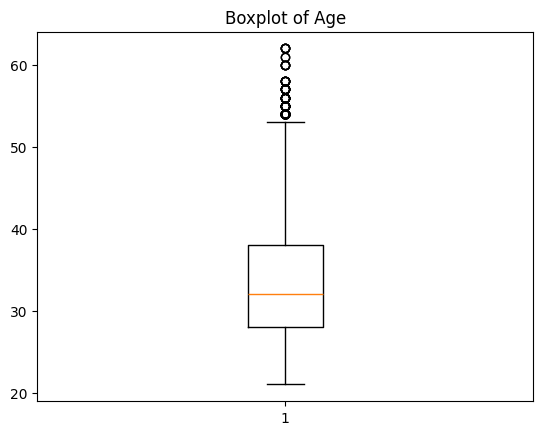

In [61]:
#Outlier Detection (Age)
import matplotlib.pyplot as plt
plt.boxplot(data['Age'])
plt.title("Boxplot of Age")
plt.show()

In [62]:
#Remove Age Outliers
data = data[(data['Age'] >= 18) & (data['Age'] <= 50)]

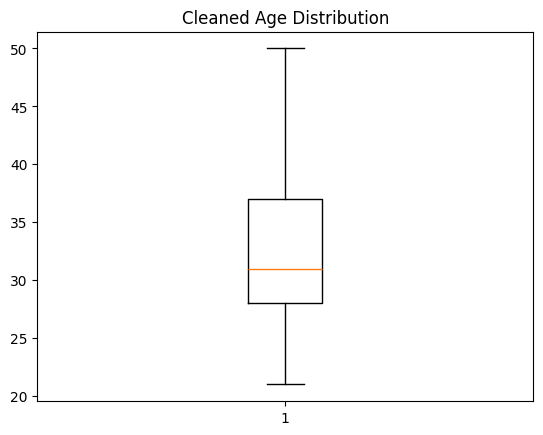

In [63]:
plt.boxplot(data['Age'])
plt.title("Cleaned Age Distribution")
plt.show()

In [64]:
#New Shape
print("New dataset shape:", data.shape)


New dataset shape: (6515, 6)


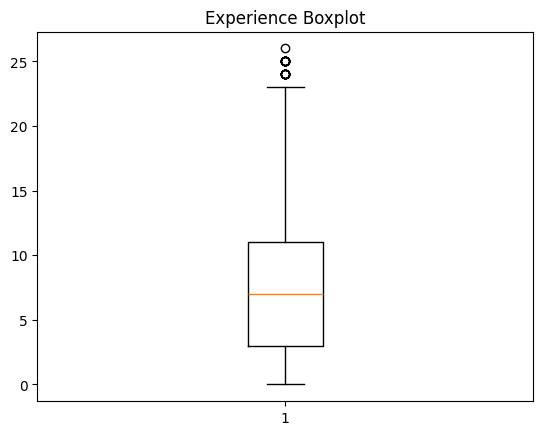

In [65]:
# Outlier Detection (Experience)

plt.boxplot(data['Years of Experience'])
plt.title("Experience Boxplot")
plt.show()

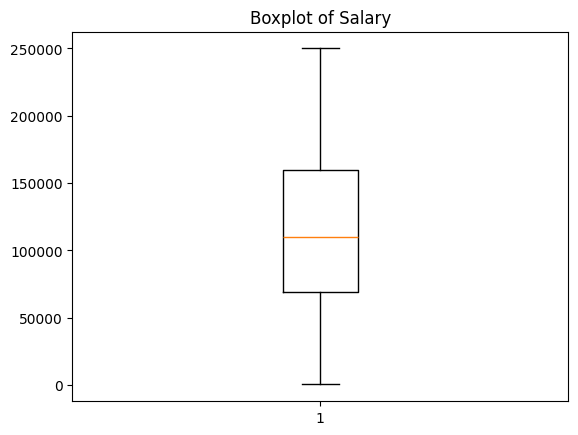

In [66]:
plt.boxplot(data['Salary'])
plt.title("Boxplot of Salary")
plt.show()


In [67]:
#Remove Salary Outliers
data = data[data['Salary'] <= 300000]

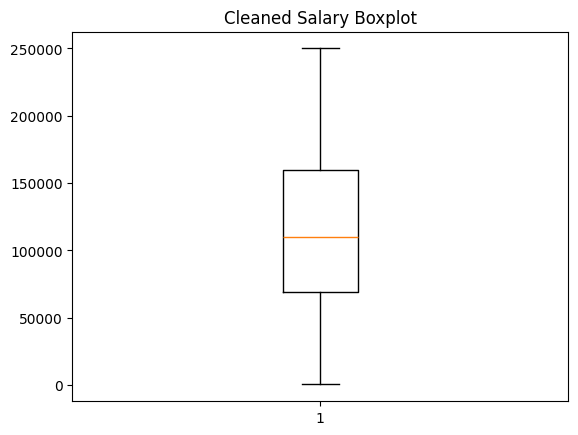

In [68]:
#Replot Salary After Cleaning
plt.boxplot(data['Salary'])
plt.title("Cleaned Salary Boxplot")
plt.show()


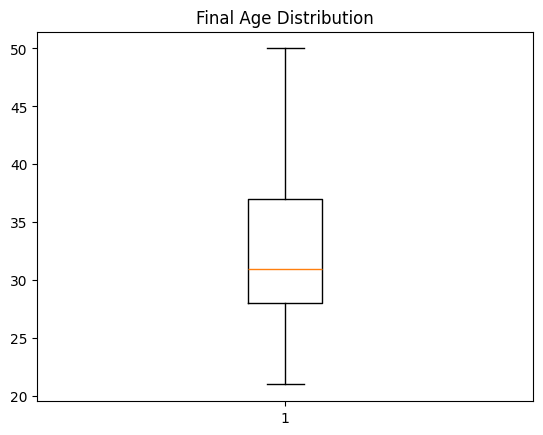

In [69]:
#Final Age Boxplot
plt.boxplot(data['Age'])
plt.title("Final Age Distribution")
plt.show()


In [70]:
# Final Shape
print("Final data shape:", data.shape)

Final data shape: (6515, 6)


In [71]:
#Drop Redundant Columns
# None redundant, so nothing dropped
pass

In [72]:
#Show Cleaned Data
data.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0


In [83]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor  # ✅ Added CatBoost

# Split the data
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define regression models including CatBoost
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "GradientBoosting": GradientBoostingRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)  # ✅ CatBoostRegressor added
}

# Store R² scores for comparison
results = {}

# Train and evaluate each model
for name, model in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    results[name] = r2

    print(f"🔹 {name} R² Score: {r2:.4f}")
    print(f"   MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"   MSE: {mean_squared_error(y_test, y_pred):.2f}\n")


🔹 LinearRegression R² Score: 0.7104
   MAE: 21869.59
   MSE: 770648780.46

🔹 RandomForest R² Score: 0.9694
   MAE: 3080.05
   MSE: 81409317.73

🔹 KNN R² Score: 0.9512
   MAE: 4294.70
   MSE: 129818743.16

🔹 SVR R² Score: 0.0101
   MAE: 44214.19
   MSE: 2633939164.46

🔹 GradientBoosting R² Score: 0.9265
   MAE: 10140.31
   MSE: 195577533.60

🔹 CatBoost R² Score: 0.9708
   MAE: 4973.88
   MSE: 77576262.57



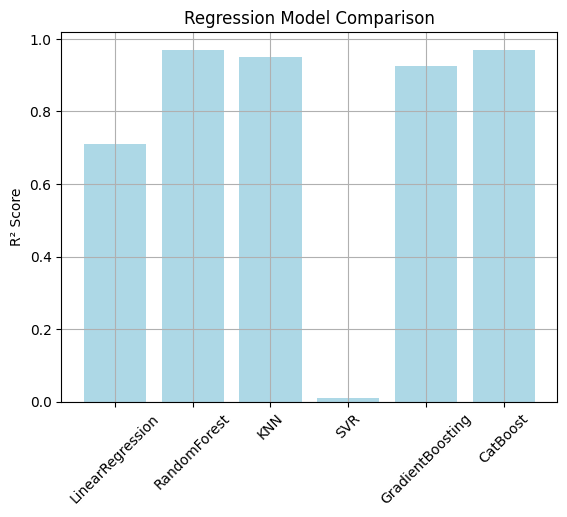

In [84]:
plt.bar(results.keys(), results.values(), color='lightblue')
plt.ylabel('R² Score')
plt.title('Regression Model Comparison')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor  # ✅ Added CatBoost
import joblib

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Define regression models including CatBoost
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "GradientBoosting": GradientBoostingRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)  # ✅ Added CatBoost (silent mode)
}

results = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    results[name] = r2
    print(f"{name}: {r2:.4f}")

# Select and save the best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
print(f"\n✅ Best model: {best_model_name} with R² = {results[best_model_name]:.4f}")
joblib.dump(best_model, "best_model.pkl")
print("✅ Saved best model as best_model.pkl")


LinearRegression: 0.7104
RandomForest: 0.9703
KNN: 0.9570
SVR: -0.0030
GradientBoosting: 0.9270
CatBoost: 0.9708

✅ Best model: CatBoost with R² = 0.9708
✅ Saved best model as best_model.pkl


In [87]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import time

# Page configuration
st.set_page_config(
    page_title="Employee Salary Prediction",
    page_icon="💰",
    layout="centered",
    initial_sidebar_state="expanded",
    menu_items={
        'About': "Professional Salary Prediction Tool - Estimate employee compensation based on key attributes"
    }
)

# Custom CSS with professional styling
st.markdown("""
<style>
    /* Main content styling */
    .main {
        background: linear-gradient(135deg, #f5f7fa 0%, #e4e7f1 100%);
        padding: 3rem 4rem;
        border-radius: 20px;
        box-shadow: 0 10px 30px rgba(0,0,0,0.08);
        max-width: 1100px;
        margin: 2rem auto;
        position: relative;
        overflow: hidden;
    }

    /* Decorative elements */
    .main::before {
        content: "";
        position: absolute;
        top: -100px;
        right: -100px;
        width: 300px;
        height: 300px;
        border-radius: 50%;
        background: linear-gradient(135deg, #4a8fe740 0%, #0066cc40 100%);
        z-index: 0;
    }

    .main::after {
        content: "";
        position: absolute;
        bottom: -150px;
        left: -150px;
        width: 400px;
        height: 400px;
        border-radius: 50%;
        background: linear-gradient(135deg, #4a8fe720 0%, #0066cc20 100%);
        z-index: 0;
    }

    /* Header styling */
    .header {
        color: #1a3e6e;
        padding-bottom: 1.2rem;
        border-bottom: 2px solid #d1e3ff;
        margin-bottom: 2rem;
        position: relative;
        z-index: 2;
    }

    /* Card styling */
    .card {
        background: white;
        border-radius: 16px;
        box-shadow: 0 6px 20px rgba(0,0,0,0.05);
        padding: 2rem;
        margin-bottom: 2rem;
        border-left: 6px solid #4a8fe7;
        position: relative;
        z-index: 2;
        transition: all 0.3s ease;
        overflow: hidden;
    }

    .card:hover {
        transform: translateY(-5px);
        box-shadow: 0 12px 25px rgba(0,0,0,0.1);
    }

    .card::before {
        content: "";
        position: absolute;
        top: 0;
        right: 0;
        width: 100px;
        height: 100px;
        background: linear-gradient(135deg, #4a8fe710 0%, #0066cc10 100%);
        border-radius: 0 0 0 100%;
    }

    /* Sidebar styling */
    .sidebar .sidebar-content {
        background: linear-gradient(152deg, #1a3e6e 0%, #2c5282 100%);
        color: white !important;
        padding: 2rem 1.5rem !important;
        border-radius: 20px !important;
        box-shadow: 0 8px 25px rgba(0,0,0,0.15) !important;
        position: relative;
        overflow: hidden;
    }

    .sidebar .sidebar-content::before {
        content: "";
        position: absolute;
        bottom: -50px;
        right: -50px;
        width: 200px;
        height: 200px;
        background: linear-gradient(135deg, #ffffff10 0%, #a0c4ff10 100%);
        border-radius: 50%;
        opacity: 0.2;
    }

    /* Sidebar header */
    .sidebar .sidebar-content h2 {
        color: #ffffff !important;
        border-bottom: 1px solid #4a8fe7;
        padding-bottom: 0.7rem !important;
        margin-bottom: 1.5rem !important;
        position: relative;
        z-index: 2;
    }

    /* Sidebar input labels */
    .sidebar .stSlider label,
    .sidebar .stSelectbox label,
    .sidebar .stRadio label {
        color: #e0f0ff !important;
        font-weight: 600 !important;
        font-size: 1rem !important;
        text-shadow: 0 1px 2px rgba(0,0,0,0.2);
    }

    /* Slider styling */
    .sidebar .stSlider {
        margin-bottom: 1.8rem !important;
        background-color: rgba(26, 62, 110, 0.5) !important;
        padding: 1rem 1.2rem !important;
        border-radius: 12px !important;
        border: 1px solid #3a7bd5 !important;
        position: relative;
        z-index: 2;
    }
    .sidebar .stSlider .thumb {
        background-color: #4a8fe7 !important;
        border: 3px solid white !important;
        box-shadow: 0 2px 8px rgba(0,0,0,0.3);
    }
    .sidebar .stSlider .track {
        background-color: #3a7bd5 !important;
    }

    /* Selectbox styling */
    .sidebar .stSelectbox > div > div {
        background-color: rgba(26, 62, 110, 0.5) !important;
        border: 1px solid #3a7bd5 !important;
        color: white !important;
        border-radius: 10px !important;
        padding: 0.8rem !important;
        box-shadow: 0 2px 5px rgba(0,0,0,0.1);
    }
    .sidebar .stSelectbox svg {
        fill: white !important;
    }

    /* Input container styling */
    .sidebar .stSelectbox {
        background-color: transparent !important;
        padding: 0 !important;
        border-radius: 10px !important;
        margin-bottom: 1.5rem !important;
        border: none !important;
    }

    /* Hover effects */
    .sidebar .stSelectbox > div > div:hover {
        border-color: #5da1ff !important;
        background-color: rgba(26, 62, 110, 0.7) !important;
    }

    /* Focus effects */
    .sidebar .stSelectbox > div > div:focus-within {
        border-color: #5da1ff !important;
        box-shadow: 0 0 0 3px rgba(93, 161, 255, 0.3) !important;
    }

    /* Dropdown menu styling */
    .sidebar .stSelectbox [role="listbox"] {
        background-color: #1a3e6e !important;
        border: 1px solid #3a7bd5 !important;
        color: white !important;
        border-radius: 10px;
        box-shadow: 0 5px 15px rgba(0,0,0,0.2);
    }
    .sidebar .stSelectbox [role="option"] {
        color: white !important;
        padding: 0.8rem 1rem;
    }
    .sidebar .stSelectbox [role="option"]:hover {
        background-color: #2c5282 !important;
    }

    /* Button styling */
    .stButton > button {
        background: linear-gradient(135deg, #4a8fe7 0%, #2c6bc5 100%);
        color: white;
        font-weight: bold;
        padding: 0.9rem 1.8rem;
        width: 100%;
        border-radius: 12px;
        transition: all 0.4s;
        border: none;
        font-size: 1.1rem;
        box-shadow: 0 4px 15px rgba(74, 143, 231, 0.3);
        position: relative;
        overflow: hidden;
        z-index: 1;
    }

    .stButton > button::before {
        content: '';
        position: absolute;
        top: 0;
        left: 0;
        width: 0%;
        height: 100%;
        background: linear-gradient(135deg, #5da1ff 0%, #3a7bd5 100%);
        transition: all 0.4s;
        z-index: -1;
    }

    .stButton > button:hover {
        transform: translateY(-3px);
        box-shadow: 0 8px 20px rgba(74, 143, 231, 0.4);
    }

    .stButton > button:hover::before {
        width: 100%;
    }

    /* Success message styling */
    .stAlert {
        border-radius: 16px;
        padding: 1.2rem;
    }

    /* Table styling */
    table.dataframe {
        width: 100%;
        border-collapse: separate;
        border-spacing: 0;
        border-radius: 12px;
        overflow: hidden;
        box-shadow: 0 4px 12px rgba(0,0,0,0.05);
        position: relative;
        z-index: 2;
    }
    table.dataframe th {
        background: linear-gradient(135deg, #4a8fe7 0%, #2c6bc5 100%);
        color: white;
        font-weight: bold;
        text-align: left;
        padding: 1rem 1.2rem;
    }
    table.dataframe td {
        padding: 0.9rem 1.2rem;
        border-bottom: 1px solid #eef2f7;
    }
    table.dataframe tr {
        transition: all 0.2s;
    }
    table.dataframe tr:nth-child(even) {
        background-color: #f8fafd;
    }
    table.dataframe tr:nth-child(odd) {
        background-color: white;
    }
    table.dataframe tr:hover {
        background-color: #edf5ff;
        transform: translateX(5px);
    }

    /* Footer styling */
    .footer {
        text-align: center;
        padding: 1.8rem;
        color: #6b7c93;
        font-size: 0.95rem;
        border-top: 1px solid #e0e8f5;
        margin-top: 2.5rem;
        position: relative;
        z-index: 2;
        font-weight: 500;
    }

    /* Responsive adjustments */
    @media (max-width: 768px) {
        .main {
            padding: 2rem 1.5rem;
        }
    }

    /* Animations */
    @keyframes fadeInUp {
        from {
            opacity: 0;
            transform: translateY(20px);
        }
        to {
            opacity: 1;
            transform: translateY(0);
        }
    }

    @keyframes float {
        0% {
            transform: translateY(0px);
        }
        50% {
            transform: translateY(-10px);
        }
        100% {
            transform: translateY(0px);
        }
    }

    .animated {
        animation: fadeInUp 0.8s ease-out forwards;
    }

    .floating {
        animation: float 4s ease-in-out infinite;
    }

    /* Pulse animation for prediction */
    @keyframes pulse {
        0% {
            box-shadow: 0 0 0 0 rgba(74, 143, 231, 0.4);
        }
        70% {
            box-shadow: 0 0 0 15px rgba(74, 143, 231, 0);
        }
        100% {
            box-shadow: 0 0 0 0 rgba(74, 143, 231, 0);
        }
    }

    .pulse {
        animation: pulse 2s infinite;
        border-radius: 16px;
    }
</style>
""", unsafe_allow_html=True)

# Load the trained regression model
@st.cache_resource
def load_model():
    return joblib.load("best_model.pkl")

model = load_model()

# Main content container
with st.container():
    st.markdown('<div class="header">', unsafe_allow_html=True)
    col1, col2 = st.columns([1, 4])
    with col1:
        st.image("https://static.vecteezy.com/system/resources/previews/060/466/630/non_2x/pay-for-something-symbol-hand-giving-money-to-other-hand-hand-holds-dollar-banknotes-money-investments-salary-receiving-money-vector.jpg", width=100,
                 caption="", output_format="PNG", clamp=False, channels="RGB")
    with col2:
        st.markdown("<h1 style='color: #1a3e6e; margin-bottom: 0;'>Employee Salary Prediction</h1>", unsafe_allow_html=True)
        st.markdown("<p style='color: #5a7eb6; font-size: 1.1rem;'>Advanced Salary Estimation System</p>", unsafe_allow_html=True)
    st.markdown('</div>', unsafe_allow_html=True)

    st.markdown("""
    <div class='card animated' style='background: linear-gradient(135deg, #edf5ff 0%, #e1edff 100%);'>
        <div style="display: flex; align-items: center;">
            <div style="font-size: 2.5rem; margin-right: 15px;">ℹ️</div>
            <div>
                <h3 style="margin-top: 0; color: #1a3e6e;">Salary Prediction Insights</h3>
                <p style="margin-bottom: 0; color: #4a6588;">
                    This professional tool estimates employee salary based on key attributes.
                    Adjust inputs in the sidebar and click "Predict Salary" for results.
                </p>
            </div>
        </div>
    </div>
    """, unsafe_allow_html=True)

# Sidebar input features with professional dark theme
with st.sidebar:
    st.markdown("""
    <style>
        @keyframes fadeIn {
            from { opacity: 0; transform: translateY(-10px); }
            to { opacity: 1; transform: translateY(0); }
        }

        @keyframes subtlePulse {
            0% { transform: scale(1); }
            50% { transform: scale(1.02); }
            100% { transform: scale(1); }
        }

        .sidebar-header {
            animation: fadeIn 0.8s ease-out forwards;
        }

        .sidebar-subtext {
            animation: fadeIn 1s ease-out 0.3s forwards;
            opacity: 0;
        }

        .sidebar-header:hover {
            animation: subtlePulse 1.5s ease-in-out infinite;
        }
    </style>

    <div style="text-align: center; margin-bottom: 1.8rem; position: relative; z-index: 2;">
        <div class="sidebar-header"
             style="color: #ffffff;
                    margin-bottom: 0.8rem;
                    font-family: 'Montserrat', 'Segoe UI', sans-serif;
                    font-size: 1.8rem;
                    font-weight: 700;
                    letter-spacing: 0.8px;
                    text-shadow: 0 2px 4px rgba(0,0,0,0.2);
                    padding: 0.2rem 0;
                    background: linear-gradient(135deg, #4a8fe7 0%, #2c6bc5 100%);
                    -webkit-background-clip: text;
                    -webkit-text-fill-color: transparent;
                    background-clip: text;">
            EMPLOYEE ATTRIBUTES
        </div>
        <div class="sidebar-subtext"
             style="color: #c5d9ff;
                    font-size: 1.05rem;
                    font-family: 'Open Sans', 'Segoe UI', sans-serif;
                    font-weight: 500;
                    letter-spacing: 0.4px;
                    margin-top: -0.5rem;
                    background: linear-gradient(135deg, #4a8fe7 0%, #2c6bc5 100%);
                    padding: 0.5rem 1rem;
                    border-radius: 50px;
                    display: inline-block;
                    backdrop-filter: blur(4px);">
            Customize the parameters below ▼
        </div>
    </div>
    """, unsafe_allow_html=True)

    # Age Slider
    age = st.slider(
        "**Age**",
        18, 50, 30,
        help="Select the employee's age"
    )

    # Gender Selectbox
    gender = st.selectbox(
        "**Gender**",
        ["Male", "Female", "Other"],
        help="Select the employee's gender identity"
    )

    # Education Selectbox
    education = st.selectbox(
        "**Education Level**",
        ["High School", "Bachelor's", "Master's", "PhD", "Unknown"],
        help="Select the highest education level"
    )

    # Job Title Selectbox
    job_title = st.selectbox(
        "**Job Title**",
        ["Software Engineer", "Data Scientist", "Manager", "HR", "Sales", "Other"],
        help="Select the employee's job role"
    )

    # Experience Slider
    experience = st.slider(
        "**Years of Experience**",
        0, 40, 5,
        help="Select years of professional experience"
    )

# Manual encoding
gender_map = {"Male": 0, "Female": 1, "Other": 2}
education_map = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3,
    "Unknown": 4
}
job_title_map = {
    "Software Engineer": 0,
    "Data Scientist": 1,
    "Manager": 2,
    "HR": 3,
    "Sales": 4,
    "Other": 5
}

# Input dataframe for prediction
input_df = pd.DataFrame({
    'Age': [age],
    'Gender': [gender_map[gender]],
    'Education Level': [education_map[education]],
    'Job Title': [job_title_map[job_title]],
    'Years of Experience': [experience]
})

# Create a styled table for display
styled_df = input_df.T.reset_index()
styled_df.columns = ['Attribute', 'Value']

# Format values for display
def format_value(row):
    if row['Attribute'] == 'Gender':
        return gender
    elif row['Attribute'] == 'Education Level':
        return education
    elif row['Attribute'] == 'Job Title':
        return job_title
    return row['Value']

styled_df['Value'] = styled_df.apply(format_value, axis=1)

# Display input data in a professional card
st.markdown("""
<div class='card animated'>
    <div style="display: flex; align-items: center; margin-bottom: 1.5rem; border-bottom: 1px solid #eef2f7; padding-bottom: 1rem;">
        <div style="font-size: 2rem; margin-right: 12px; color: #4a8fe7;">🔍</div>
        <h3 style="margin: 0; color: #1a3e6e;">Input Summary</h3>
    </div>
""", unsafe_allow_html=True)

# Display the styled table
st.table(styled_df.style
         .set_properties(**{'background-color': 'transparent',
                           'color': '#2c3e50',
                           'border': 'none'})
         .hide(axis='index'))

# Close the card div
st.markdown("</div>", unsafe_allow_html=True)

# Predict button with enhanced styling
col1, col2, col3 = st.columns([1, 2, 1])
with col2:
    if st.button("**PREDICT SALARY**", key="predict_button", type="primary"):
        with st.spinner('Analyzing salary factors...'):
            time.sleep(1.5)  # Simulate processing time
            prediction = model.predict(input_df)

            # Format the salary with commas
            formatted_salary = f"${prediction[0]:,.2f}"

            st.markdown(f"""
            <div class='card pulse' style="background: linear-gradient(135deg, #e8f5e9 0%, #d1e7dd 100%);
                     text-align: center; margin-top: 1.5rem; position: relative;">
                <div style="position: absolute; top: 20px; right: 20px; font-size: 2.5rem; color: #2e7d32;">💰</div>
                <h2 style="color: #2e7d32; margin-top: 1rem; font-weight: 700;">ESTIMATED SALARY</h2>
                <p style="font-size: 3rem; font-weight: bold; color: #1b5e20; margin: 1rem 0; letter-spacing: 1px;">
                    {formatted_salary}
                </p>
                <div style="display: inline-block; background-color: rgba(43, 108, 176, 0.1);
                     padding: 0.5rem 1.5rem; border-radius: 50px; margin-bottom: 1rem;">
                    <p style="color: #4a6588; margin: 0; font-weight: 500;">
                        Based on provided attributes
                    </p>
                </div>
            </div>
            """, unsafe_allow_html=True)

# Additional information section
with st.expander("📊 How This Prediction Works ", expanded=False):
    st.markdown("""
1) Data Collection: We start by collecting employee data such as age, gender, education level, job title, experience, and salary.

2) Data Preprocessing:
   a) We clean the data by removing outliers (e.g., age > 50).

   b) Then we convert text values (like job title or gender) into numbers using label encoding, because machine learning models only understand numbers.

3) Feature Selection: Important features like age, education, job, etc., are chosen to train the model. These features help the model understand what affects a person’s salary.

4) Model Training & Testing:

  We train multiple machine learning models like:

	Linear Regression
	Random Forest
	KNN
	SVR
	Gradient Boosting
	CatBoost (which performed best)

  Then we compare them using scores like: R² Score (fit quality),MAE, RMSE (error sizes)

5) Best Model Selection: We select the model with the best performance — here, CatBoost Regressor, which gave the most accurate results.

6) Making Predictions: When the user inputs their data (age, job, etc.), the model predicts their salary based on the patterns it learned.

7) Streamlit Web App: A Streamlit app lets users interact easily. They select their details and click a button to see their predicted salary instantly.
    """, unsafe_allow_html=True)

# Footer
st.markdown("""
<div class="footer">
    <div style="font-size: 1.8rem; color: #4a8fe7; margin-bottom: 0.8rem;">💼</div>
    <div>© 2025 Employee Salary Prediction | <span style="color: #4a8fe7; font-weight: 600;">Advanced Salary System</span></div>
    <div style="margin-top: 0.5rem; font-size: 0.9rem; color: #7f8fa8;">
        This tool provides estimates based on proprietary algorithms. Actual salary may vary based on additional factors.
    </div>
</div>
""", unsafe_allow_html=True)

Writing app.py


In [88]:
!streamlit run app.py





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.196.174.222:8501

  Stopping...
  Stopping...
Exception ignored in atexit callback: <function shutdown at 0x7b693e429800>
Traceback (most recent call last):
  File "/usr/lib/python3.11/logging/__init__.py", line 2185, in shutdown
    h.flush()
  File "/usr/lib/python3.11/logging/__init__.py", line 989, in flush
    def flush(self):

  File "/usr/local/lib/python3.11/dist-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/usr/local/lib/python3.11/dist-packages/streamlit/web/server/server.py", line 458, in stop
    self._runtime.stop()
  File "/usr/local/lib/python3.11/dist-packages/streamlit/runtime/runtime.py", line 324, in stop
    async_objs.eventloop.call_soon_threadsafe(stop_on_eventloop)
  File "/usr/lib/python3.11/asyncio/base_events.py", line 807, in call_soon_threadsafe
    self._c